# HOMEWORK 15

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [48]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization, RandomRotation, RandomFlip
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [16]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

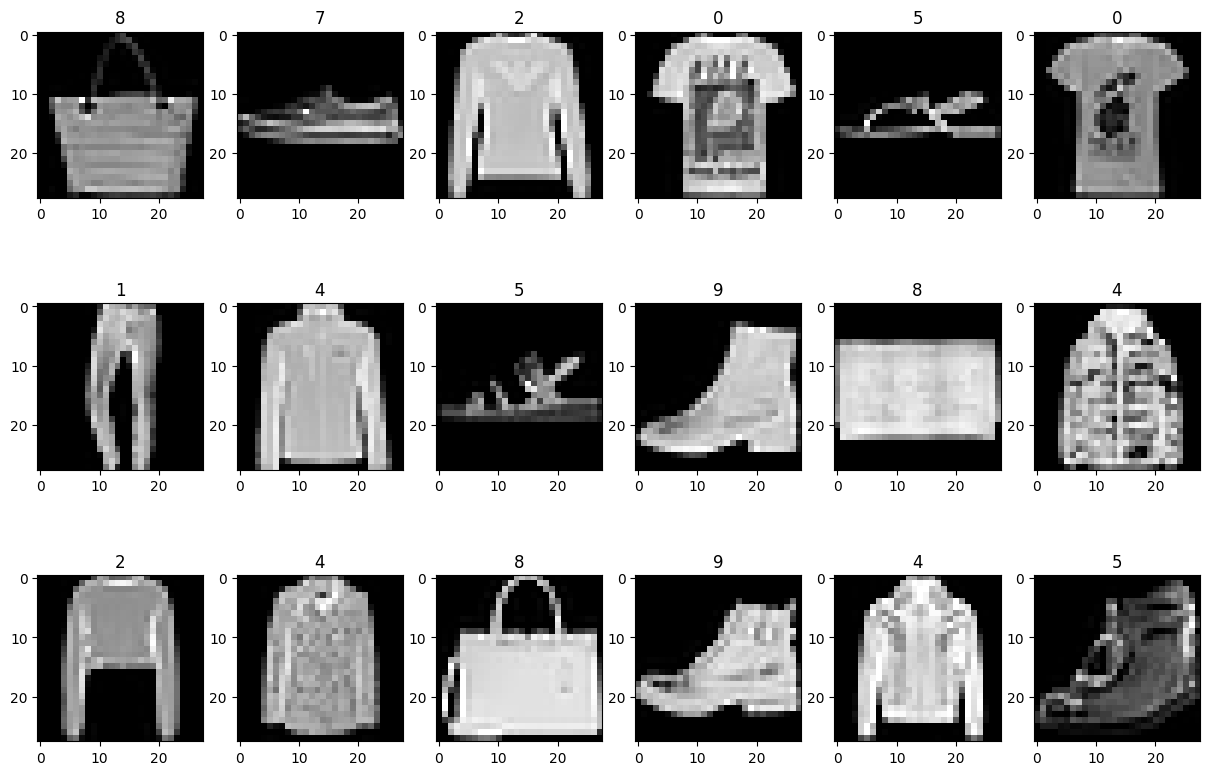

In [19]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [22]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [24]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
epochs = 50
batch_size = 64

model.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam", 
    metrics=["accuracy"]
)
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.8634 - loss: 0.3918 - val_accuracy: 0.8829 - val_loss: 0.3248
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9061 - loss: 0.2635 - val_accuracy: 0.8900 - val_loss: 0.3040
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9199 - loss: 0.2224 - val_accuracy: 0.8926 - val_loss: 0.3020
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.9308 - loss: 0.1932 - val_accuracy: 0.8915 - val_loss: 0.3126
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9390 - loss: 0.1696 - val_accuracy: 0.8936 - val_loss: 0.3320
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9472 - loss: 0.1496 - val_accuracy: 0.8915 - val_loss: 0.3602
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9541 - loss: 0.1324 - val_accuracy: 0.8835 - val_loss: 0.4130
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9596 - loss: 0.1175 - 

In [30]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

Train Acc      0.9939333200454712
Validation Acc 0.8755999803543091


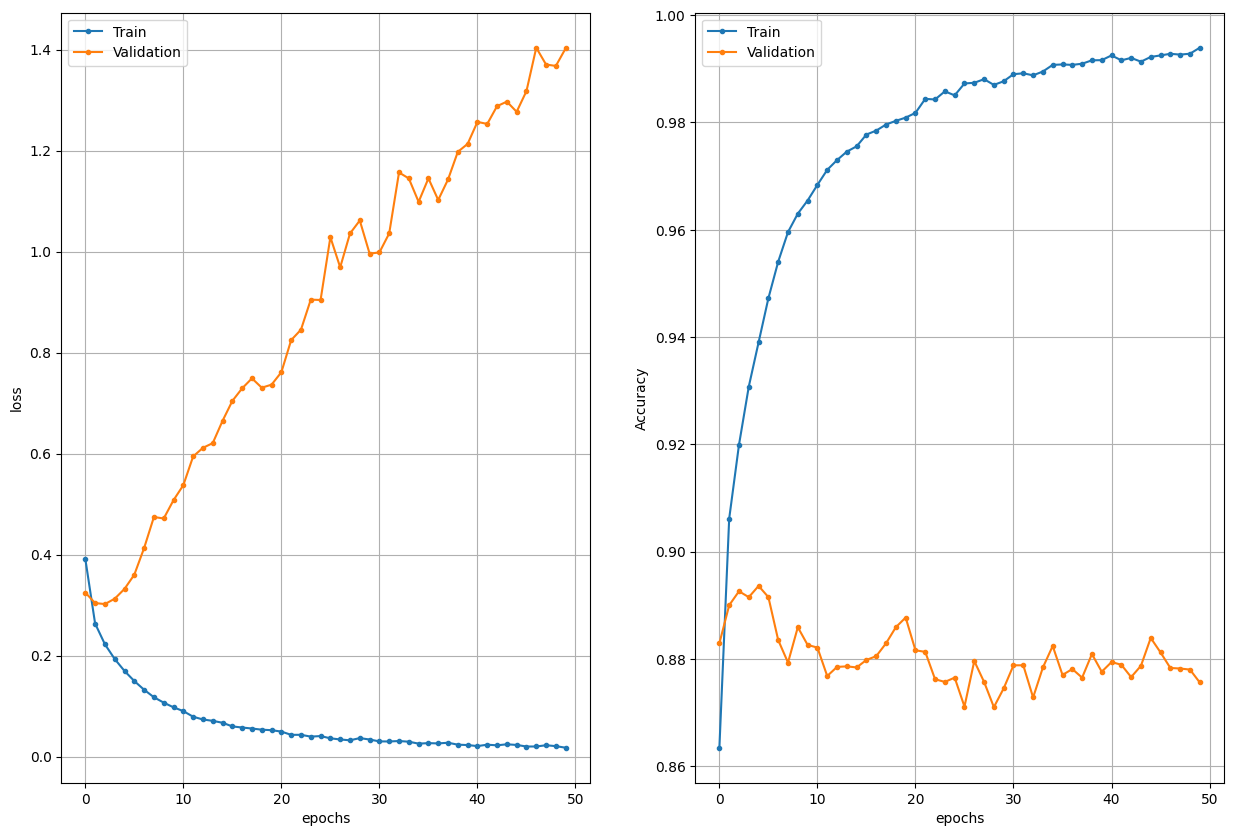

In [32]:
plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout (Під час тренування мережі випадково "вимикається" певна частина нейронів (разом із їхніми зв’язками) на кожній ітерації навчання.)
  x = Dropout(0.5)(x)
  50% нейронів тимчасово не беруть участі в обчисленнях під час поточного проходу
    1. Без Dropout модель може "запам’ятати" тренувальні дані (overfitting)
    2. Dropout змушує мережу не покладатися на конкретні нейрони, а розподіляти знання по різних шляхах.
    3. Це робить модель більш узагальнюючою (generalizable) — вона краще працює на нових, невідомих зображеннях.

  
* Batch normalization (BN) — допомагає мережі навчатися швидше, стабільніше й краще узагальнювати. Під час навчання значення активацій (виходів нейронів) можуть сильно змінюватися між шарами — це називають internal covariate shift. Batch Normalization вирівнює (нормалізує) ці значення, щоб зробити розподіл більш стабільним.


* Weight regularization - допомагає зменшити перенавчання (overfitting), контролюючи величину ваг (weights) моделі. Ідея: Під час навчання нейронна мережа може підганяти ваги під тренувальні дані занадто сильно. Щоб уникнути цього, ми додаємо штраф (penalty) до функції втрат (loss function) за занадто великі ваги.
    Ефект:
    1. Модель стає менш схильною до перенавчання
    2. Ваги стають меншими та стабільнішими
    3. Часто допомагає отримати кращу генералізацію на нових даних


* Data augmentation - допомагає зробити модель стійкішою та зменшити перенавчання, штучно збільшуючи кількість тренувальних зображень.
    Ідея: Замість того щоб збирати більше фото вручну, ми генеруємо нові варіації існуючих зображень, змінюючи їх випадковим, але контрольованим чином (наприклад, поворот, зсув, віддзеркалення тощо). Тобто кожного разу, коли модель бачить зображення, воно трохи інше.


* Early stopping - допомагає запобігти перенавчанню (overfitting), зупиняючи тренування моделі вчасно, коли вона перестає покращуватись.
    Суть ідеї: Під час навчання нейронної мережі зазвичай точність (accuracy) на тренувальних даних зростає, але на валідаційних даних (validation set) після певного моменту — починає падати. Це означає, що модель запам’ятала тренувальні приклади і більше не узагальнює. Early stopping автоматично зупиняє тренування, коли валідаційна метрика не покращується кілька епох поспіль.



* Pooling - базова операція в Computer Vision, яка використовується в Convolutional Neural Networks (CNN) для зменшення розміру зображення після згортки (convolution), зберігаючи при цьому найважливішу інформацію.
    Суть ідеї: Після того, як фільтри (Conv2D) витягли ознаки (features), нам не потрібно зберігати кожен піксель. Pooling бере невелике вікно (наприклад, 2×2) і замінює його одним числом — найважливішим показником у цьому регіоні.
    Це допомагає:
        1. зменшити розмірність (менше параметрів → швидше навчання),
        2. зменшити overfitting
        3. зробити модель стійкішою до зсувів, поворотів, шуму.


* Reducing the number of parameters (the size of the network) - (зменшення кількості параметрів нейромережі) — це ще один важливий спосіб знизити перенавчання, прискорити тренування і зробити модель ефективнішою (особливо у Computer Vision, де моделі можуть бути дуже “важкими”).
    Що означає “зменшити кількість параметрів”
    Параметри в нейромережі — це ваги (weights) і зміщення (biases), які навчаються.
      Їхня кількість визначається: кількістю шарів, кількістю нейронів у шарах, розміром ядер (filters) у згорткових шарах, і способом підключення шарів.
    Більше параметрів = більша потужність, але й вищий ризик перенавчання та повільніше навчання.


* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

In [35]:
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust

# inputs = Input(shape=(28, 28, 1))
# net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
# net = Flatten()(net)
# net = Dense(128)(net)
# outputs = Dense(10, activation="softmax")(net)

inputs = Input(shape=(28, 28, 1))
net = Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same")(inputs) #Зменшення кількості фільтрів у Conv2D: 32 --> 16
net = Dropout(0.2)(net) #add
net = MaxPooling2D(pool_size=(2, 2))(net)
# Після кожного Conv2D часто додають MaxPooling2D(2,2) — це зменшує розмір карти ознак (наприклад, з 64×64 до 32×32), 
#і отже, менше параметрів у наступних шарах.
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same")(net)
net = Dropout(0.2)(net)
net = Flatten()(net)
net = Dense(32)(net) # Зменшення кількості нейронів у Dense.
net = Dropout(0.5)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,866 (804.16 KB)

 Trainable params: 205,866 (804.16 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train the network
epochs = 50
batch_size = 64

model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8135 - loss: 0.5446 - val_accuracy: 0.8734 - val_loss: 0.3681
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8688 - loss: 0.3840 - val_accuracy: 0.8870 - val_loss: 0.3270
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8854 - loss: 0.3356 - val_accuracy: 0.8949 - val_loss: 0.2907
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8954 - loss: 0.3060 - val_accuracy: 0.8908 - val_loss: 0.2959
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9022 - loss: 0.2861 - val_accuracy: 0.9023 - val_loss: 0.2671
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9070 - loss: 0.2705 - val_accuracy: 0.9065 - val_loss: 0.2556
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9110 - loss: 0.2580 - val_accuracy: 0.9053 - val_loss: 0.2560
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9142 - loss: 0.2485 - 

Train Acc      0.9449166655540466
Validation Acc 0.920199990272522


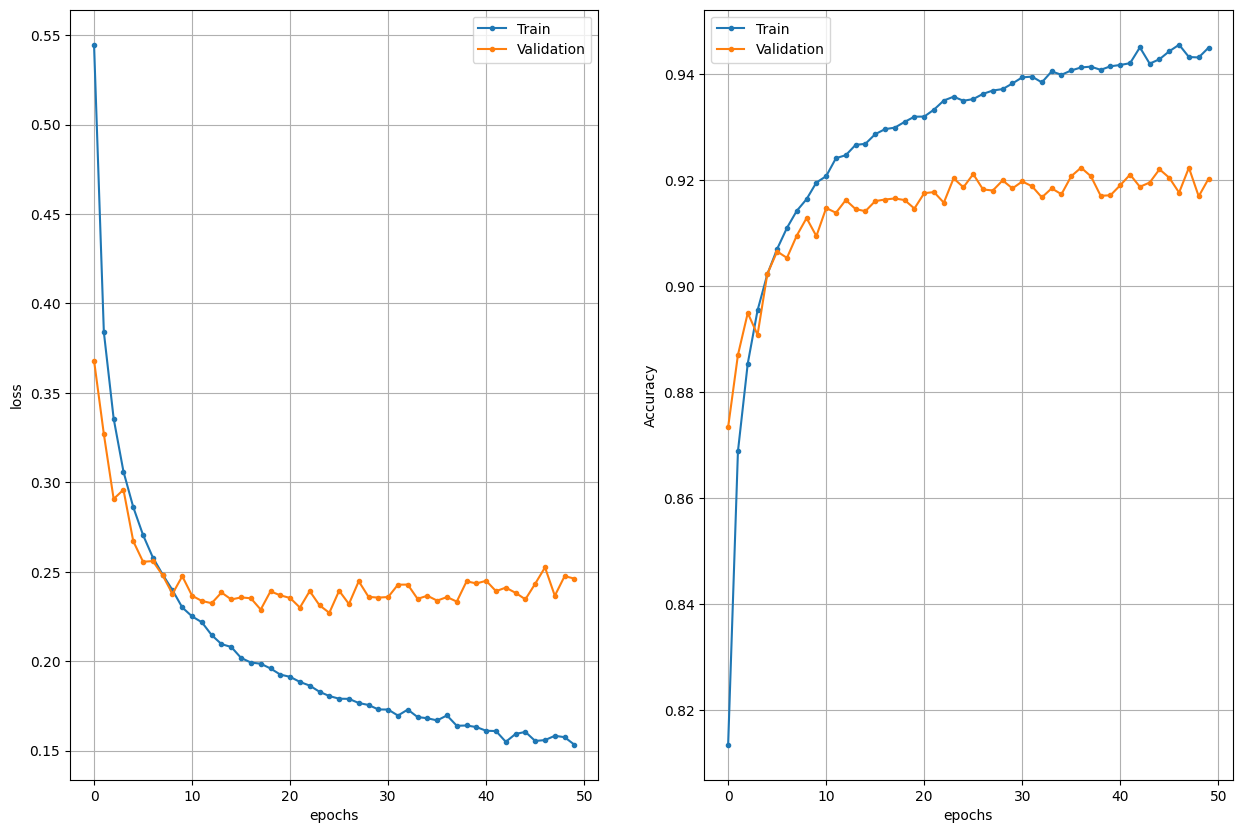

In [39]:
# Show the results
plot_history(history)

In [50]:
inputs = Input(shape=(28, 28, 1))
net = RandomRotation(0.2)(inputs)
net = RandomFlip("horizontal")(net)
net = Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same")(net)
net = Flatten()(net)
net = Dense(32)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,866 (804.16 KB)

 Trainable params: 205,866 (804.16 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
epochs = 50
batch_size = 64

model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)
start = time()
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
)
print('Elapsed time', time() - start)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.7030 - loss: 0.8554 - val_accuracy: 0.7584 - val_loss: 0.6955
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.7878 - loss: 0.6032 - val_accuracy: 0.8006 - val_loss: 0.5742
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8141 - loss: 0.5270 - val_accuracy: 0.8167 - val_loss: 0.5629
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8286 - loss: 0.4850 - val_accuracy: 0.8131 - val_loss: 0.5586
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8384 - loss: 0.4531 - val_accuracy: 0.8263 - val_loss: 0.5332
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8433 - loss: 0.4393 - val_accuracy: 0.8279 - val_loss: 0.5145
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8511 - loss: 0.4201 - val_accuracy: 0.8250 - val_loss: 0.5332
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8543 - loss: 0.4103 - 

Train Acc      0.888949990272522
Validation Acc 0.8636000156402588


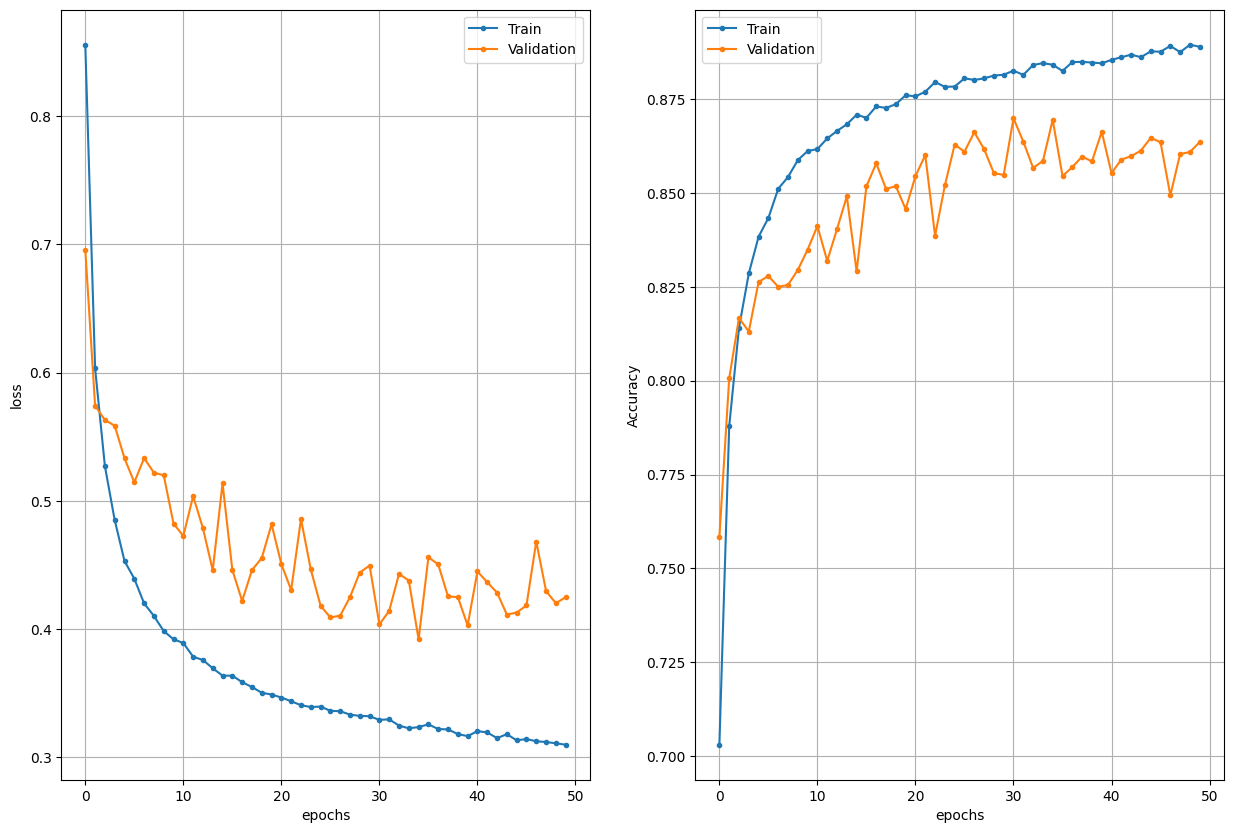

In [55]:
plot_history(history)

### Questions

* What have you done in order to improve the performance?
    Додано більше шарів та зменшено розмір мережі, використано dropout, batch normalization, weight constraints, data augmentation та early stopping разом із learning rate scheduling.

* Have you tried configurations that did not work out?
  ні, пробував різні конфігурації